## Importing Dependencies

In [1]:
# imports
import os
from pathlib import Path
from tqdm import tqdm
import cv2
import filetype
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image
import hashlib
from sklearn.model_selection import train_test_split
import shutil
import numpy as np

## Path Setup & Class Detection

In [2]:
# setting up source & output paths
SOURCE_DIR = Path("data/original_images")
OUTPUT_DIR = Path("data/split")

# create output directory if not exist yet
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# checking for classes
CLASS_NAMES = sorted([p.name for p in SOURCE_DIR.iterdir() if p.is_dir()])
print("Detected classes:", CLASS_NAMES)

Detected classes: ['ballpoint', 'binder', 'files', 'headphone', 'mouse', 'mug']


## Image Verification & Collection

1. check if image is readable
2. validate file type has correct extensions {'jpeg', 'jpg', 'bmp', 'png'}
3. check if image is RGB (3 channels) if not convert to RBG
4. remove all invalid files that can't be converted or isn't readable

In [4]:
# valid file extensions
image_extensions = ['jpeg', 'jpg', 'bmp', 'png']

rows = []

for cls in CLASS_NAMES:
    folder = SOURCE_DIR / cls
    print(f"Checking {cls} ...")
    
    for image_file in tqdm(os.listdir(folder)):
        image_path = folder / image_file

        if not image_path.is_file():
            continue  
        try:
            # Read image
            img = cv2.imread(str(image_path))
            kind = filetype.guess(str(image_path))

            # Validate using cv2 and filetype
            if img is None or kind is None or kind.extension not in image_extensions:
                print(f"Invalid or unreadable image: {image_path}")
                os.remove(image_path)
                continue

            # Check if image is RGB
            if len(img.shape) == 2:  
                # grayscale (H, W)
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                cv2.imwrite(str(image_path), img)
                print(f"Converted grayscale to RGB: {image_path}")
            elif img.shape[2] == 4:  
                # RGBA (H, W, 4)
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
                cv2.imwrite(str(image_path), img)
                print(f"Removed alpha channel (converted RGBA to RGB): {image_path}")

            # Store valid image info
            rows.append({"filepath": str(image_path), "label": cls})

        except Exception as e:
            print(f"Error reading image {image_path}: {e}")
            os.remove(image_path)

Checking ballpoint ...


100%|██████████| 1236/1236 [00:00<00:00, 3443.39it/s]


Checking binder ...


 19%|█▉        | 294/1519 [00:00<00:00, 2935.24it/s]

Invalid or unreadable image: data/original_images/binder/.DS_Store


...

100%|██████████| 1318/1318 [00:00<00:00, 3573.19it/s]


Checking mug ...


 32%|███▏      | 492/1559 [00:00<00:00, 4917.93it/s]

Invalid or unreadable image: data/original_images/mug/.DS_Store


100%|██████████| 1559/1559 [00:00<00:00, 5136.26it/s]


## Create Dataframe & Save as CSV

In [5]:
# create dataframe
df_office = pd.DataFrame(rows)
print(f"\nTotal verified images: {len(df_office)}")

# Shuffle rows
df_office = df_office.sample(frac=1).reset_index(drop=True)



Total verified images: 8238


In [6]:
# save df as csv
csv_path = "data/office_items.csv"
df_office.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

Saved CSV: data/office_items.csv


## Data Preprocessing & Analysis

In [7]:
# print dataframe
df_office

,filepath,label
0,data/original_images/ballpoint/DBBAPAB2KVCF.jpg,ballpoint
1,data/original_images/files/RRBNJVJEFMJF_aug.jpg,files
2,data/original_images/mouse/2MTJ2MYUX7BD.jpg,mouse
3,data/original_images/files/7JZOQYT3NK5E.jpg,files
4,data/original_images/mug/I5ZBHRUH18KB.jpg,mug
...,...,...
8233,data/original_images/files/7CEFMNC0SU2Z.jpg,files
8234,data/original_images/mouse/0VJITJRWHS5G.jpg,mouse
8235,data/original_images/files/SYY8Z2TG1D3A.jpg,files
8236,data/original_images/mouse/6WWU4IDXQI9O.jpg,mouse


In [8]:
# number of rows & columns
df_office.shape

(8238, 2)

In [9]:
# check for missing values
df_office.isnull().sum()

filepath    0
label       0
dtype: int64

In [10]:
# check for duplicate images using hash
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df_office['hash'] = df_office['filepath'].apply(file_hash)

# Find duplicates
duplicates = df_office[df_office.duplicated('hash', keep=False)]
print(f"Found {len(duplicates)} duplicate images.")

Found 105 duplicate images.


In [11]:
# drop duplicate images using the hash column
df_office.drop_duplicates(subset=['hash'], inplace=True)
print(f"After removing duplicates: {len(df_office)} images remain.")

After removing duplicates: 8182 images remain.


In [12]:
# File extensions in dataset
print(df_office['filepath'].apply(lambda x: Path(x).suffix.lower()).value_counts())

filepath
.jpg     7862
.jpeg     198
.png      122
Name: count, dtype: int64


Distribution of classes

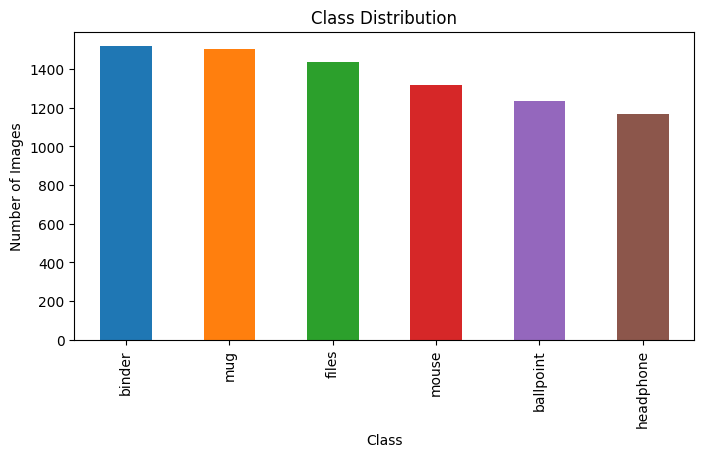

Imbalance Ratio: 1.30


In [13]:
# Count how many samples per label
class_counts = df_office['label'].value_counts()

# Plot distribution
plt.figure(figsize=(8,4))
class_counts.plot(
    kind='bar',
    color=plt.cm.tab10.colors[:len(class_counts)] 
)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# check imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")


Visualize Samples

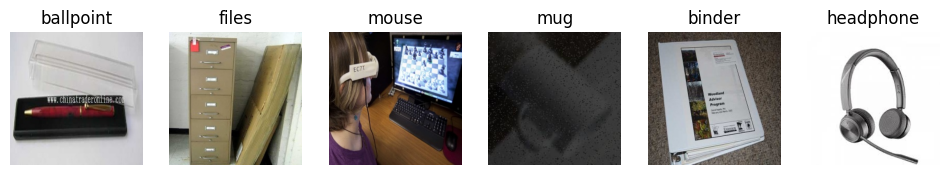

In [19]:
# Pick random samples from each class
classes = df_office['label'].unique()
plt.figure(figsize=(12, 6))

for i, c in enumerate(classes):
    sample = random.choice(df_office[df_office['label'] == c]['filepath'].values)
    img = Image.open(sample)
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis('off')

plt.show()


## Train, Val & Test split

train -> 80 %   
test -> 10 %  
val -> 10 %

In [22]:
trainval, test = train_test_split(df_office, test_size=0.10, stratify=df_office['label'], random_state=99)
train, val = train_test_split(trainval, test_size=0.111111, stratify=trainval['label'], random_state=99)

In [23]:
print(f"Split counts -> Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Split counts -> Train: 6544, Val: 819, Test: 819


## Copy images to ImageFolder layout

In [24]:
def copy_to_split(split_df, split_name):
    missing_files = []
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Copying {split_name}"):
        src = Path(row['filepath'])
        if not src.exists():
            missing_files.append(src)
            continue  
        dst_dir = OUTPUT_DIR / split_name / row['label']
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / src.name
        if not dst.exists():
            shutil.copy(src, dst)
    if missing_files:
        print(f"Skipped {len(missing_files)} missing files:")
        for f in missing_files:
            print(f"  {f}")

copy_to_split(train, "train")
copy_to_split(val, "val")
copy_to_split(test, "test")


Copying test: 100%|██████████| 819/819 [00:00<00:00, 6073.88it/s]


## Dataset Mean & STD

In [25]:
def compute_mean_std(df_subset):
    means, stds = [], []
    for p in tqdm(df_subset['filepath'], desc="Computing mean/std"):
        img = Image.open(p).convert("RGB")
        arr = np.asarray(img, dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0,1)))
        stds.append(arr.std(axis=(0,1)))
    mean = np.mean(means, axis=0)
    std = np.mean(stds, axis=0)
    return mean, std

mean, std = compute_mean_std(train.sample(200))
print("Mean:", mean)
print("Std :", std)

Computing mean/std: 100%|██████████| 200/200 [00:00<00:00, 704.83it/s]

Mean: [0.52008516 0.49953845 0.48316428]
Std : [0.21664025 0.21551804 0.21414994]
